<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/Dataset_fc_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
import kagglehub

# 1. Descargar el dataset
path = kagglehub.dataset_download("nyagami/fc-24-players-database-and-stats-from-easports")

# 2. Listar los archivos para saber el nombre exacto del CSV
files = os.listdir(path)
print("Archivos encontrados:", files)

# 3. Cargar el archivo principal (normalmente se llama 'all_players.csv' o similar)
# Asumiendo que el archivo principal está en la lista de archivos:
csv_file = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

# 4. Ver las primeras filas y las columnas disponibles
print(df.head())
print(df.info())

Using Colab cache for faster access to the 'fc-24-players-database-and-stats-from-easports' dataset.
Archivos encontrados: ['all_fc_24_players.csv', 'male_fc_24_players.csv', 'female_fc_24_players.csv']
   Unnamed: 0             name   nation             club position  \
0           0    Kylian Mbappé   France         Paris SG       ST   
1           1  Alexia Putellas    Spain     FC Barcelona       CM   
2           2   Erling Haaland   Norway  Manchester City       ST   
3           3  Kevin De Bruyne  Belgium  Manchester City       CM   
4           4   Aitana Bonmatí    Spain     FC Barcelona       CM   

  alternative positions  age  overall  PAC  SHO  ...  att work rate  \
0            ST, LW, CF   25       91   97   90  ...           High   
1                CM, LW   30       91   82   90  ...           High   
2                ST, CF   24       91   89   93  ...           High   
3               CM, CAM   33       91   72   88  ...           High   
4                    CM   2

# Objetivos
##1. Scouting Inteligente y Análisis de Valor
Este enfoque es ideal para entender el mercado de jugadores y cómo se relacionan las habilidades con el precio.

Objetivo: Identificar "Joyas Ocultas" (jugadores con alto potencial y bajo valor de mercado).

##2. Predicción de Valor de Mercado (Regresión)
Si quieres aplicar modelos de Machine Learning (como los MLPRegressor o Random Forest que hemos explorado antes), este es el camino.

Objetivo: Determinar qué atributos físicos o técnicos influyen más en el precio de un jugador.
##3. Agrupación de Perfiles (Clustering)
A veces, la posición "oficial" de un jugador no define su rol real en la cancha.

Objetivo: Clasificar a los jugadores en roles modernos (ej: "Lateral con llegada", "Box-to-Box", "Falso 9").

##4. Sistema de Recomendación (Similaridad)
Ideal para recrear la lógica de un director deportivo.

Objetivo: Construir un motor de "Búsqueda por Similaridad".

In [ ]:
# 1. Eliminar porteros (GK)
# Filtramos para mantener solo a los que NO tienen la posición 'GK'
df_field = df[df['position'] != 'GK'].copy()

# 2. Limpiar Height (ej: '180cm' -> 180)
# Usamos una expresión regular para extraer solo los dígitos al inicio de la cadena
df_field['height'] = df_field['height'].str.extract('(\d+)').astype(int)

# 3. Limpiar Weight (ej: '75kg' -> 75)
# Usamos una expresión regular para extraer solo los dígitos al inicio de la cadena
df_field['weight'] = df_field['weight'].str.extract('(\d+)').astype(int)

# 4. Eliminar las columnas de portero que ya no sirven
cols_gk = ['GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes']
df_field = df_field.drop(columns=cols_gk)

print(f"Jugadores restantes: {df_field.shape[0]}")

Jugadores restantes: 15834


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_13606/103768791.py:7: SyntaxWarning: invalid escape sequence '\d'
  df_field['height'] = df_field['height'].str.extract('(\d+)').astype(int)
/tmp/ipykernel_13606/103768791.py:11: SyntaxWarning: invalid escape sequence '\d'
  df_field['weight'] = df_field['weight'].str.extract('(\d+)').astype(int)


In [ ]:
print(df_field.head())
print(df_field.info())

   Unnamed: 0             name   nation             club position  \
0           0    Kylian Mbappé   France         Paris SG       ST   
1           1  Alexia Putellas    Spain     FC Barcelona       CM   
2           2   Erling Haaland   Norway  Manchester City       ST   
3           3  Kevin De Bruyne  Belgium  Manchester City       CM   
4           4   Aitana Bonmatí    Spain     FC Barcelona       CM   

  alternative positions  age  overall  PAC  SHO  ...  height  weight  \
0            ST, LW, CF   25       91   97   90  ...     182      75   
1                CM, LW   30       91   82   90  ...     173      67   
2                ST, CF   24       91   89   93  ...     195      94   
3               CM, CAM   33       91   72   88  ...     181      75   
4                    CM   26       90   81   84  ...     161      51   

   preferred foot  weak foot             league  att work rate  def work rate  \
0           Right          4  Ligue 1 Uber Eats           High         

In [ ]:
import numpy as np

# 1. Definimos los multiplicadores de posición (Los delanteros suelen ser más caros)
pos_multipliers = {
    'ST': 1.2, 'CF': 1.2, 'LW': 1.15, 'RW': 1.15,
    'CAM': 1.1, 'CM': 1.05, 'CDM': 1.0,
    'CB': 0.95, 'LB': 0.95, 'RB': 0.95
}

def build_market_features(df):
    # --- CREACIÓN DE ÍNDICES TÉCNICOS ---
    # Ataque
    df['atk_score'] = df[['Finishing', 'Positioning', 'Shot Power', 'Volleys']].mean(axis=1)
    # Creación
    df['playmaking_score'] = df[['Vision', 'Short Passing', 'Long Passing', 'Crossing']].mean(axis=1)
    # Defensa
    df['def_score'] = df[['Interceptions', 'Def Awareness', 'Standing Tackle']].mean(axis=1)

    # --- LÓGICA DE VALORACIÓN SINTÉTICA ---
    def calculate_value(row):
        # Base exponencial: Un jugador de 90 vale muchísimo más que uno de 80
        # Usamos (Overall/10)^4 para crear esa curva de crecimiento real
        value = (row['overall'] / 10)**4.5 * 5000

        # Factor Edad: Los jóvenes (18-23) valen un 40% más por potencial
        if row['age'] <= 23:
            value *= 1.4
        # Los veteranos (>32) pierden valor de mercado
        elif row['age'] > 32:
            value *= 0.6

        # Factor Posición: Aplicamos el multiplicador de la tabla
        # Si la posición no está (ej: un 'LWB'), usamos 1.0 por defecto
        mult = pos_multipliers.get(row['position'], 1.0)
        value *= mult

        # Bonus por "Meta": Si es muy rápido (PAC > 85), su valor sube
        if row['PAC'] > 85:
            value *= 1.2

        return round(value, -3) # Redondeamos al millar más cercano

    df['market_value'] = df.apply(calculate_value, axis=1)
    return df

# Aplicamos las funciones
df_field = build_market_features(df_field)

# Veamos los resultados
print(df_field[['name', 'age', 'overall', 'position', 'market_value']].head(10))

                      name  age  overall position  market_value
0            Kylian Mbappé   25       91       ST   148943000.0
1          Alexia Putellas   30       91       CM   108604000.0
2           Erling Haaland   24       91       ST   148943000.0
3          Kevin De Bruyne   33       91       CM    65162000.0
4           Aitana Bonmatí   26       90       CM   103336000.0
5             Lionel Messi   37       90       CF    70859000.0
6                 Sam Kerr   30       90       ST   118098000.0
7            Karim Benzema   36       90       CF    70859000.0
9               Harry Kane   31       90       ST   118098000.0
10  Caroline Graham Hansen   29       90       RW   135813000.0


In [ ]:
df_field.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15834 entries, 0 to 18095
Data columns (total 57 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             15834 non-null  int64  
 1   name                   15834 non-null  object 
 2   nation                 15834 non-null  object 
 3   club                   15834 non-null  object 
 4   position               15834 non-null  object 
 5   alternative positions  15834 non-null  object 
 6   age                    15834 non-null  int64  
 7   overall                15834 non-null  int64  
 8   PAC                    15834 non-null  int64  
 9   SHO                    15834 non-null  int64  
 10  PAS                    15834 non-null  int64  
 11  DRI                    15834 non-null  int64  
 12  DEF                    15834 non-null  int64  
 13  PHY                    15834 non-null  int64  
 14  Acceleration           15834 non-null  int64  
 15  Sprint 

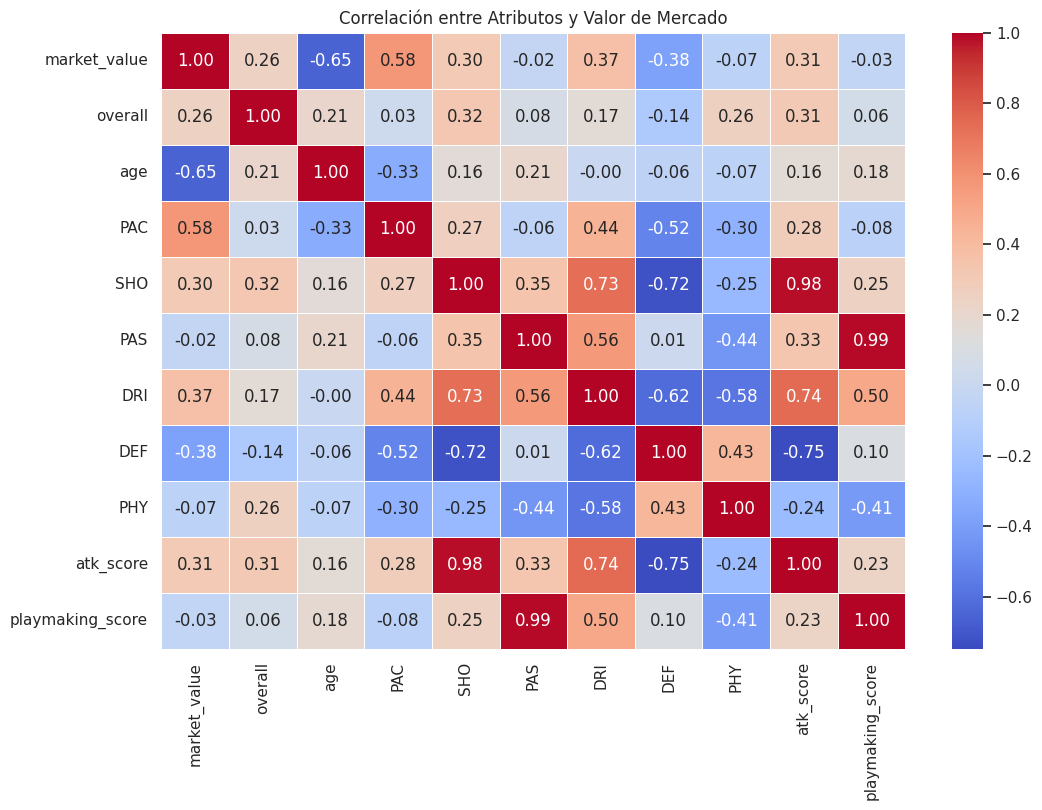

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las variables más importantes para no saturar el gráfico
cols_interes = ['market_value', 'overall', 'age', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'atk_score', 'playmaking_score']
corr_matrix = df_field[cols_interes].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlación entre Atributos y Valor de Mercado')
plt.show()

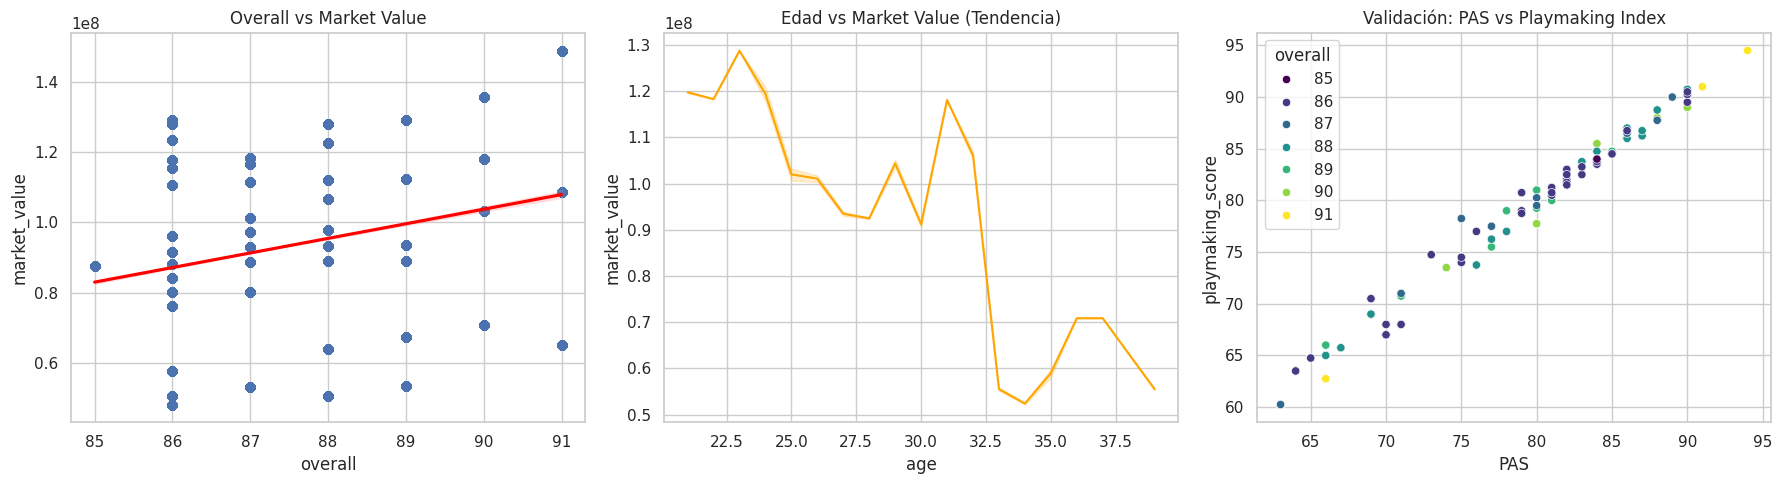

In [ ]:
plt.figure(figsize=(18, 5))

# Gráfico 1: Overall vs Market Value
plt.subplot(1, 3, 1)
sns.regplot(data=df_field, x='overall', y='market_value', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Overall vs Market Value')

# Gráfico 2: Age vs Market Value
plt.subplot(1, 3, 2)
sns.lineplot(data=df_field, x='age', y='market_value', color='orange')
plt.title('Edad vs Market Value (Tendencia)')

# Gráfico 3: PAS vs playmaking_score (Validación de tu Feature)
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_field, x='PAS', y='playmaking_score', hue='overall', palette='viridis')
plt.title('Validación: PAS vs Playmaking Index')

plt.tight_layout()
plt.show()